# Технологии ИИ ЛР №1: Задача повышения разрешения изображения
*Выполнил Владимир Недугов 6231-010402D*

В связи с различными ограничениями устройств для фото- и видеосъемки качество получаемых данных может быть недостаточным для решения целого ряда задач, например, для идентификации номеров автомобилей, лиц людей и т.д. Для решения таких проблем используются методы повышения разрешения изображений.

## Постановка задачи 
На вход подается изображение малого разрешения. На выходе получается исходное изображение с большим разрешением.

**Вход**: Изображение низкого разрешения в формате *.png*, *.bmp*, *.jpg*

**Выход**: Исходное изображение с восстановленным высоким разрешением
 

## Пример набора данных
Для данной задачи набор данных можно создать самим из имеющихся открытых датасетов (ImageNet, CoCo и т.д.) с помощью инструментов понижения размерности изображений (например, в cv2 метод resize()).

## Предлагаемые архитектуры
•	SRGAN (https://arxiv.org/abs/1609.04802)

---
### Источники
"ПРАКТИКУМ
ПО КУРСУ «ТЕХНОЛОГИИ ИСКУССТВЕННОГО ИНТЕЛЛЕКТА И НЕЙРОСЕТЕВОЙ АНАЛИЗ ДАННЫХ»", авторы: Н.С. Давыдов, А.В. Никоноров

Для обучения использовалось: 

- **NVIDIA RTX 4080 Super 16 GB**
- **96 GB RAM**

## Обучение

1. MSE-pretrain генератора SRResNet.
2. GAN-фаза с VGG54 content loss + adversarial loss.
3. Дообучение GAN с меньшим learning rate.

## Данные

Используется (**DIV2K**)[https://data.vision.ee.ethz.ch/cvl/DIV2K/].

- Все HR-изображения один раз загружаются в RAM.
- Во время обучения из RAM берутся случайные HR-crop `96×96`.
- LR строится на лету bicubic-downsampling'ом ×4.

## 1. Установка зависимостей

In [ ]:
%pip install -q torch torchvision torchmetrics matplotlib tqdm pillow

## 2. Импорты и конфигурация

In [ ]:
from pathlib import Path
import math
import random
import os

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchvision import transforms
from torchvision.models import vgg19, VGG19_Weights
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF
from torchvision.datasets.utils import download_and_extract_archive
from tqdm.auto import tqdm
from IPython.display import clear_output

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda")

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

print("GPU:", torch.cuda.get_device_name(0))
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print("PyTorch:", torch.__version__)

SCALE = 4
HR_CROP = 96
LR_CROP = HR_CROP // SCALE

BATCH_SIZE = 16

NUM_WORKERS = 0
PIN_MEMORY = True

STEPS_PER_EPOCH = 500
TRAIN_PATCHES_PER_EPOCH = STEPS_PER_EPOCH * BATCH_SIZE

VAL_CROP = 256
VAL_MAX_IMAGES = 40

PRETRAIN_STEPS = 60_000
GAN_HIGH_STEPS = 30_000
GAN_LOW_STEPS = 10_000

PRETRAIN_EPOCHS = math.ceil(PRETRAIN_STEPS / STEPS_PER_EPOCH)
GAN_HIGH_EPOCHS = math.ceil(GAN_HIGH_STEPS / STEPS_PER_EPOCH)
GAN_LOW_EPOCHS = math.ceil(GAN_LOW_STEPS / STEPS_PER_EPOCH)

# MSE-pretrain
PRETRAIN_LR = 1e-4

# Плавная адаптация MSE -> VGG54 без дискриминатора
VGG_ONLY_EPOCHS = 8
VGG_ONLY_LR = 1e-5

# GAN: дискриминатор специально не делаем слишком быстрым
GAN_G_LR_HIGH = 1e-5
GAN_D_LR_HIGH = 2e-5

GAN_G_LR_LOW = 1e-5
GAN_D_LR_LOW = 1e-5

# Adversarial loss включается постепенно
ADV_TARGET_WEIGHT = 1e-3
ADV_WARMUP_STEPS = 10_000

D_UPDATE_EVERY = 1

AMP_ENABLED = True
AMP_DTYPE = torch.float16

DATA_DIR = Path("data")
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Полный checkpoint для resume текущего запуска
CHECKPOINT_PATH = CHECKPOINT_DIR / "srgan_div2k_latest.pt"

# Старый/общий best checkpoint (оставляем для совместимости)
BEST_PATH = CHECKPOINT_DIR / "srgan_div2k_best_ssim.pt"

# тут только лучший генератор после MSE-pretrain, без D и optimizer state.
PRETRAIN_GENERATOR_PATH = CHECKPOINT_DIR / "best_pretrain_generator.pt"

print(
    f"crop={HR_CROP}, batch={BATCH_SIZE}, steps/epoch={STEPS_PER_EPOCH}\n"
    f"pretrain={PRETRAIN_EPOCHS} epochs (~{PRETRAIN_EPOCHS * STEPS_PER_EPOCH:,} steps)\n"
    f"vgg-only={VGG_ONLY_EPOCHS} epochs\n"
    f"gan high={GAN_HIGH_EPOCHS} epochs (~{GAN_HIGH_EPOCHS * STEPS_PER_EPOCH:,} steps)\n"
    f"gan low={GAN_LOW_EPOCHS} epochs (~{GAN_LOW_EPOCHS * STEPS_PER_EPOCH:,} steps)"
)

f:\ysda\ml1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GeForce RTX 4080 SUPER
VRAM: 16.0 GB
PyTorch: 2.9.1+cu130
crop=96, batch=16, steps/epoch=500
pretrain=120 epochs (~60,000 steps)
vgg-only=8 epochs
gan high=60 epochs (~30,000 steps)
gan low=20 epochs (~10,000 steps)


## 3. Датасет

Используются только HR-изображения. LR-пара строится по hr bicubic-downsampling'ом ×4.

Во время обучения каждый вызов берет случайный `96×96` HR crop и применяет случайные flip/rotation. Поэтому даже 800 исходных DIV2K training images дают огромное число разных патчей.

In [ ]:
DIV2K_ROOT = DATA_DIR / "DIV2K"
TRAIN_DIR = DIV2K_ROOT / "DIV2K_train_HR"
VAL_DIR = DIV2K_ROOT / "DIV2K_valid_HR"

DIV2K_URLS = {
    "train": "https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip",
    "val": "https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip",
}

def ensure_div2k():
    DIV2K_ROOT.mkdir(parents=True, exist_ok=True)
    if not TRAIN_DIR.exists():
        print("Скачивание DIV2K train HR...")
        download_and_extract_archive(
            DIV2K_URLS["train"],
            download_root=str(DIV2K_ROOT),
            filename="DIV2K_train_HR.zip",
            remove_finished=False,
        )
    if not VAL_DIR.exists():
        print("Скачивание DIV2K validation HR...")
        download_and_extract_archive(
            DIV2K_URLS["val"],
            download_root=str(DIV2K_ROOT),
            filename="DIV2K_valid_HR.zip",
            remove_finished=False,
        )

ensure_div2k()

train_files = sorted(TRAIN_DIR.glob("*.png"))
val_files = sorted(VAL_DIR.glob("*.png"))[:VAL_MAX_IMAGES]

print("DIV2K train:", len(train_files))
print("DIV2K val used:", len(val_files))

DIV2K train: 800
DIV2K val used: 40


In [ ]:
class ImageRAMCache:
    """
    Все изображения DIV2K один раз загружаются в RAM как uint8 [C,H,W].
    """

    def __init__(self, files, desc):
        self.files = list(files)
        self.images = []

        print(f"Загрузка {len(self.files)} изображений в RAM...")
        for path in tqdm(self.files, desc=desc):
            img = Image.open(path).convert("RGB")
            arr = np.array(img, dtype=np.uint8, copy=True)
            tensor = torch.from_numpy(arr).permute(2, 0, 1).contiguous()
            self.images.append(tensor)

        print(f"{desc}: готово.")

    def get(self, idx):
        return self.images[idx]


train_cache = ImageRAMCache(train_files, "DIV2K train -> RAM")
val_cache = ImageRAMCache(val_files, "DIV2K val -> RAM")


class DIV2KRandomPatchDataset(Dataset):
    """Случайные HR-патчи; LR строится bicubic downsampling ×4."""

    def __init__(self, files, cache, patches_per_epoch):
        self.files = list(files)
        self.cache = cache
        self.patches_per_epoch = patches_per_epoch

    def __len__(self):
        return self.patches_per_epoch

    def __getitem__(self, idx):
        image_idx = idx % len(self.files)
        img_u8 = self.cache.get(image_idx)

        _, h, w = img_u8.shape

        top = random.randint(0, h - HR_CROP)
        left = random.randint(0, w - HR_CROP)

        crop = img_u8[:, top:top + HR_CROP, left:left + HR_CROP]

        if random.random() < 0.5:
            crop = torch.flip(crop, dims=[2])

        if random.random() < 0.5:
            crop = torch.flip(crop, dims=[1])

        k = random.randint(0, 3)
        if k:
            crop = torch.rot90(crop, k=k, dims=[1, 2])

        # В float переводится только маленький crop.
        hr = crop.float().div_(255.0)

        lr = TF.resize(
            hr,
            [LR_CROP, LR_CROP],
            interpolation=InterpolationMode.BICUBIC,
            antialias=True,
        )

        return lr.clamp(0, 1), hr.clamp(0, 1)


class DIV2KValidationDataset(Dataset):
    def __init__(self, files, cache):
        self.files = list(files)
        self.cache = cache

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = self.cache.get(idx).float().div_(255.0)

        _, h, w = img.shape
        top = (h - VAL_CROP) // 2
        left = (w - VAL_CROP) // 2

        hr = img[:, top:top + VAL_CROP, left:left + VAL_CROP]

        lr = TF.resize(
            hr,
            [VAL_CROP // SCALE, VAL_CROP // SCALE],
            interpolation=InterpolationMode.BICUBIC,
            antialias=True,
        )

        return lr.clamp(0, 1), hr.clamp(0, 1)


train_ds = DIV2KRandomPatchDataset(
    train_files,
    train_cache,
    TRAIN_PATCHES_PER_EPOCH,
)

val_ds = DIV2KValidationDataset(
    val_files,
    val_cache,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=True,
)

lr, hr = next(iter(train_loader))

print("LR:", tuple(lr.shape))
print("HR:", tuple(hr.shape))
print("DIV2K полностью находится в RAM.")

Загрузка 800 изображений в RAM...


DIV2K train -> RAM: 100%|██████████| 800/800 [00:36<00:00, 22.06it/s]


DIV2K train -> RAM: готово.
Загрузка 40 изображений в RAM...


DIV2K val -> RAM: 100%|██████████| 40/40 [00:01<00:00, 21.36it/s]


DIV2K val -> RAM: готово.
LR: (16, 3, 24, 24)
HR: (16, 3, 96, 96)
DIV2K полностью находится в RAM.


## 4. SRGAN-VGG54 архитектура

In [ ]:
class SRResBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)


class SRGANGenerator(nn.Module):
    """16 residual blocks + два PixelShuffle ×2."""

    def __init__(self):
        super().__init__()
        self.head = nn.Sequential(
            nn.Conv2d(3, 64, 9, padding=4),
            nn.PReLU(),
        )
        self.body = nn.Sequential(*[SRResBlock(64) for _ in range(16)])
        self.body_tail = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
        )
        self.up = nn.Sequential(
            nn.Conv2d(64, 256, 3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU(),
            nn.Conv2d(64, 256, 3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU(),
            nn.Conv2d(64, 3, 9, padding=4),
        )

    def forward_raw(self, lr_rgb):
        features = self.head(lr_rgb)
        residual = self.body_tail(self.body(features))
        return self.up(features + residual)

    def forward(self, lr_rgb):
        return ((self.forward_raw(lr_rgb) + 1.0) / 2.0).clamp(0, 1)


class SRGANDiscriminator(nn.Module):
    """Дискриминатор для HR crop 96×96, близкий к Figure 4 SRGAN."""

    def __init__(self):
        super().__init__()

        def block(in_ch, out_ch, stride, use_bn):
            layers = [
                nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1),
            ]
            if use_bn:
                layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        layers = []
        spec = [
            (3, 64, 1, False),
            (64, 64, 2, True),
            (64, 128, 1, True),
            (128, 128, 2, True),
            (128, 256, 1, True),
            (256, 256, 2, True),
            (256, 512, 1, True),
            (512, 512, 2, True),
        ]
        for args in spec:
            layers += block(*args)

        self.features = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 6 * 6, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 1),
        )

    def forward(self, hr_normalized):
        return self.classifier(self.features(hr_normalized))


class VGG54ContentLoss(nn.Module):
    """
    VGG19 relu5_4 features.
    Деление feature maps на 12.75 повторяет масштабирование,
    описанное в training details оригинальной статьи.
    """

    def __init__(self):
        super().__init__()
        self.features = vgg19(weights=VGG19_Weights.DEFAULT).features[:36].eval()
        self.features.requires_grad_(False)

        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def extract(self, x_normalized):
        rgb01 = (x_normalized + 1.0) / 2.0
        x = (rgb01 - self.mean) / self.std
        return self.features(x) / 12.75

    def forward(self, pred_normalized, target_normalized):
        pred_feat = self.extract(pred_normalized)
        with torch.no_grad():
            target_feat = self.extract(target_normalized)

        # Сумма по каналам, среднее по N,H,W.
        return (pred_feat - target_feat).square().sum(dim=1).mean()


G = SRGANGenerator().to(device)
D = SRGANDiscriminator().to(device)
vgg_loss_fn = VGG54ContentLoss().to(device)
bce = nn.BCEWithLogitsLoss()

print(f"G params: {sum(p.numel() for p in G.parameters()):,}")
print(f"D params: {sum(p.numel() for p in D.parameters()):,}")

G params: 1,549,462
D params: 23,565,505


## 5. Метрики

Как и в ориганальной статье используются метрики PSNR/SSIM и дополнительно MSE и MAE

\begin{align}
\mathrm{MSE}   &= \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2 \\[4pt]
\mathrm{PSNR}  &= 10\log_{10}\!\frac{\mathrm{MAX}^2}{\mathrm{MSE}} \\[4pt]
\mathrm{SSIM}  &= \frac{(2\mu_x\mu_y + C_1)(2\sigma_{xy} + C_2)}
                       {(\mu_x^2 + \mu_y^2 + C_1)(\sigma_x^2 + \sigma_y^2 + C_2)}
\end{align}

Для PSNR/SSIM используется Y-канал и удаляются 4 пикселя по краям, чтобы оценивание было ближе к протоколу статьи.  
Train-метрики считаются на текущих batch'ах; validation - на фиксированной части DIV2K validation.

In [ ]:
def rgb_to_y(x):
    r, g, b = x[:, 0:1], x[:, 1:2], x[:, 2:3]
    return 0.299 * r + 0.587 * g + 0.114 * b


class SRMetricTracker:
    def __init__(self, metric_device):
        self.metric_device = metric_device
        self.ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(metric_device)
        self.squared_error = 0.0
        self.absolute_error = 0.0
        self.pixel_count = 0

    @torch.no_grad()
    def update(self, pred_rgb, target_rgb):
        pred = pred_rgb.detach().clamp(0, 1)
        target = target_rgb.detach().clamp(0, 1)

        pred = rgb_to_y(pred)
        target = rgb_to_y(target)

        shave = SCALE
        pred = pred[..., shave:-shave, shave:-shave]
        target = target[..., shave:-shave, shave:-shave]

        error = pred - target
        self.squared_error += error.square().sum().item()
        self.absolute_error += error.abs().sum().item()
        self.pixel_count += error.numel()
        self.ssim.update(pred, target)

    def compute(self):
        mse = self.squared_error / max(self.pixel_count, 1)
        psnr = float("inf") if mse == 0 else -10.0 * math.log10(mse)
        return {
            "MSE": mse,
            "MAE": self.absolute_error / max(self.pixel_count, 1),
            "PSNR_dB": psnr,
            "SSIM": self.ssim.compute().item(),
        }


@torch.no_grad()
def evaluate_generator():
    G.eval()
    tracker = SRMetricTracker(device)

    for lr, hr in tqdm(val_loader, desc="validation", leave=False):
        lr = lr.to(device, non_blocking=True)
        hr = hr.to(device, non_blocking=True)

        with torch.autocast(
            device_type=device.type,
            dtype=AMP_DTYPE,
            enabled=AMP_ENABLED,
        ):
            pred = G(lr)

        tracker.update(pred.float(), hr)

    return tracker.compute()

## 6. Вспомогательные функции

In [ ]:

history = []
training_state = {
    "phase_epochs_done": {
        "pretrain": 0,
        "vgg_only": 0,
        "gan_high": 0,
        "gan_low": 0,
    },
    "gan_step": 0,
    "best_val_ssim": -float("inf"),
    "best_pretrain_ssim": -float("inf"),
}

latest_disc_hist = {
    "real": np.array([], dtype=np.float32),
    "fake": np.array([], dtype=np.float32),
}

phase_examples = {}

g_opt = torch.optim.Adam(G.parameters(), lr=PRETRAIN_LR, betas=(0.9, 0.999))
d_opt = torch.optim.Adam(D.parameters(), lr=GAN_D_LR_HIGH, betas=(0.9, 0.999))

g_scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
d_scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)


def plot_history(redraw=True):
    if not history:
        return

    if redraw:
        clear_output(wait=True)

    x = [row["global_epoch"] for row in history]
    gan_rows = [
        r for r in history
        if r["phase"] in {"gan_high", "gan_low"}
    ]

    if not gan_rows:
        fig, axes = plt.subplots(2, 3, figsize=(16, 9))
        current_phase = history[-1]["phase"]

        title = (
            "SRGAN-VGG54 — pretrain генератора"
            if current_phase == "pretrain"
            else "SRGAN-VGG54 — VGG54-only adaptation"
        )
        fig.suptitle(title, fontsize=15)

        for metric, ax in [
            ("MSE", axes[0, 0]),
            ("MAE", axes[0, 1]),
            ("PSNR_dB", axes[1, 0]),
            ("SSIM", axes[1, 1]),
        ]:
            ax.plot(
                x,
                [r[f"train_{metric}"] for r in history],
                marker=".",
                label=f"train_{metric}",
            )
            ax.plot(
                x,
                [r[f"val_{metric}"] for r in history],
                marker=".",
                label=f"val_{metric}",
            )
            ax.set_title(metric)
            ax.set_xlabel("global epoch")
            ax.grid(True)
            ax.legend()

        axes[0, 2].plot(
            x, [r["G_loss"] for r in history],
            marker=".", 
            label="G_loss"
        )
        axes[0, 2].plot(
            x, [r["content_loss"] for r in history],
            marker=".", 
            label="content"
        )
        axes[0, 2].set_title("Generator loss")
        axes[0, 2].set_xlabel("global epoch")
        axes[0, 2].grid(True)
        axes[0, 2].legend()

        axes[1, 2].axis("off")
        plt.tight_layout()
        plt.show()
        return

    # После старта GAN показываем D-диагностику.
    fig, axes = plt.subplots(3, 3, figsize=(17, 13))
    fig.suptitle("SRGAN-VGG54 — GAN training", fontsize=15)

    for metric, ax in [
        ("MSE", axes[0, 0]),
        ("MAE", axes[0, 1]),
        ("PSNR_dB", axes[1, 0]),
        ("SSIM", axes[1, 1]),
    ]:
        ax.plot(
            x,
            [r[f"train_{metric}"] for r in history],
            marker=".",
            label=f"train_{metric}",
        )
        ax.plot(
            x,
            [r[f"val_{metric}"] for r in history],
            marker=".",
            label=f"val_{metric}",
        )
        ax.set_title(metric)
        ax.set_xlabel("global epoch")
        ax.grid(True)
        ax.legend()

    axes[0, 2].plot(
        x, [r["G_loss"] for r in history],
        marker=".", 
        label="G_loss"
    )
    axes[0, 2].plot(
        x, [r["content_loss"] for r in history],
        marker=".", 
        label="content"
    )
    axes[0, 2].plot(
        x, [r["adv_loss"] for r in history],
        marker=".",
        label="adversarial"
    )
    axes[0, 2].set_title("Generator losses")
    axes[0, 2].set_xlabel("global epoch")
    axes[0, 2].grid(True)
    axes[0, 2].legend()

    gx = [r["global_epoch"] for r in gan_rows]

    axes[1, 2].plot(
        gx,
        [r["D_loss"] for r in gan_rows],
        marker=".",
        label="D_loss",
    )
    axes[1, 2].set_title("Discriminator loss")
    axes[1, 2].set_xlabel("global epoch")
    axes[1, 2].grid(True)
    axes[1, 2].legend()

    axes[2, 0].plot(
        gx,
        [r["D_real_prob_mean"] for r in gan_rows],
        marker="o",
        label="mean D(real)",
    )
    axes[2, 0].plot(
        gx,
        [r["D_fake_prob_mean"] for r in gan_rows],
        marker="o",
        label="mean D(fake)",
    )
    axes[2, 0].axhline(0.5, linestyle="--", alpha=0.6)
    axes[2, 0].set_ylim(0, 1)
    axes[2, 0].set_title("Средние ответы дискриминатора")
    axes[2, 0].set_xlabel("global epoch")
    axes[2, 0].set_ylabel("P(real)")
    axes[2, 0].grid(True)
    axes[2, 0].legend()

    axes[2, 1].plot(
        gx,
        [100 * r["D_real_acc"] for r in gan_rows],
        marker="o",
        label="real → real",
    )
    axes[2, 1].plot(
        gx,
        [100 * r["D_fake_acc"] for r in gan_rows],
        marker="o",
        label="fake → fake",
    )
    axes[2, 1].plot(
        gx,
        [100 * r["D_acc"] for r in gan_rows],
        marker="o",
        label="total",
    )
    axes[2, 1].axhline(50, linestyle="--", alpha=0.6)
    axes[2, 1].set_ylim(0, 105)
    axes[2, 1].set_title("Точность дискриминатора")
    axes[2, 1].set_xlabel("global epoch")
    axes[2, 1].set_ylabel("%")
    axes[2, 1].grid(True)
    axes[2, 1].legend()

    real_hist = latest_disc_hist["real"]
    fake_hist = latest_disc_hist["fake"]

    if len(real_hist) and len(fake_hist):
        bins = np.linspace(0, 1, 21)
        axes[2, 2].hist(real_hist, bins=bins, alpha=0.6, density=True, label="D(real HR)")
        axes[2, 2].hist(fake_hist, bins=bins, alpha=0.6, density=True, label="D(fake SR)")
        axes[2, 2].axvline(0.5, linestyle="--", linewidth=2, label="threshold")
        axes[2, 2].set_xlim(0, 1)
        axes[2, 2].set_title( f"Распределение D(x), epoch {gan_rows[-1]['global_epoch']}")
        axes[2, 2].set_xlabel("P(real)")
        axes[2, 2].set_ylabel("density")
        axes[2, 2].grid(True)
        axes[2, 2].legend()

    for ax in axes.flat:
        for j, row in enumerate(history):
            if j > 0 and history[j - 1]["phase"] != row["phase"]:
                ax.axvline(
                    row["global_epoch"],
                    linestyle="--",
                    alpha=0.35,
                )

    plt.tight_layout()
    plt.show()


def save_pretrain_generator(path=PRETRAIN_GENERATOR_PATH):
    """Сохраняет ТОЛЬКО G — удобно для повторных GAN-экспериментов."""
    torch.save(
        {
            "G": G.state_dict(),
            "best_pretrain_ssim": training_state["best_pretrain_ssim"],
        },
        path,
    )


def save_checkpoint(path):
    """Полный checkpoint для resume текущего запуска."""
    torch.save(
        {
            "G": G.state_dict(),
            "D": D.state_dict(),
            "g_opt": g_opt.state_dict(),
            "d_opt": d_opt.state_dict(),
            "g_scaler": g_scaler.state_dict(),
            "d_scaler": d_scaler.state_dict(),
            "history": history,
            "training_state": training_state,
            "phase_examples": phase_examples,
        },
        path,
    )


def load_checkpoint(path=CHECKPOINT_PATH):
    global history, training_state, phase_examples

    ckpt = torch.load(path, map_location=device)

    G.load_state_dict(ckpt["G"])
    D.load_state_dict(ckpt["D"])

    if "g_opt" in ckpt:
        g_opt.load_state_dict(ckpt["g_opt"])
    if "d_opt" in ckpt:
        d_opt.load_state_dict(ckpt["d_opt"])

    if "g_scaler" in ckpt:
        g_scaler.load_state_dict(ckpt["g_scaler"])
    if "d_scaler" in ckpt:
        d_scaler.load_state_dict(ckpt["d_scaler"])

    history = ckpt.get("history", [])
    loaded_state = ckpt.get("training_state", {})

    # Совместимость со старым checkpoint без vgg_only/best_pretrain_ssim.
    for phase in ("pretrain", "vgg_only", "gan_high", "gan_low"):
        loaded_state.setdefault("phase_epochs_done", {}).setdefault(phase, 0)

    loaded_state.setdefault("gan_step", 0)
    loaded_state.setdefault("best_val_ssim", -float("inf"))
    loaded_state.setdefault("best_pretrain_ssim", -float("inf"))

    training_state = loaded_state
    phase_examples = ckpt.get("phase_examples", {})

    print("Checkpoint загружен:", path)
    print("state:", training_state)


def reset_discriminator():
    """Полностью сбрасывает веса D перед новой попыткой GAN."""
    for module in D.modules():
        if hasattr(module, "reset_parameters"):
            module.reset_parameters()


def prepare_new_gan_attempt_from_pretrain():
    """
    Загружает только лучший pretrain G.
    D сбрасывается, optimizer/scaler создаются заново.
    Предыдущие VGG/GAN эпохи удаляются из history.
    """
    global g_opt, d_opt, g_scaler, d_scaler
    global history, phase_examples, latest_disc_hist

    if PRETRAIN_GENERATOR_PATH.exists():
        ckpt = torch.load(PRETRAIN_GENERATOR_PATH, map_location=device)
        G.load_state_dict(ckpt["G"])
        print("G загружен из:", PRETRAIN_GENERATOR_PATH)

    elif BEST_PATH.exists():
        ckpt = torch.load(BEST_PATH, map_location=device)
        if isinstance(ckpt, dict) and "G" in ckpt:
            G.load_state_dict(ckpt["G"])
            print(
                "Отдельного pretrain-G ещё нет. "
                "G загружен из старого BEST_PATH:",
                BEST_PATH,
            )
        else:
            raise RuntimeError(
                f"{BEST_PATH} не содержит ключ 'G'. "
                "Нужно сначала сохранить/обучить pretrain generator."
            )
    else:
        raise FileNotFoundError(
            "Не найден лучший pretrain generator. "
            "Сначала запусти MSE-pretrain."
        )

    # Новый D с нуля.
    reset_discriminator()
    D.to(device)

    # Новые optimizer/scaler: никакого optimizer momentum от прошлой попытки.
    g_opt = torch.optim.Adam(
        G.parameters(), lr=VGG_ONLY_LR, betas=(0.9, 0.999)
    )
    d_opt = torch.optim.Adam(
        D.parameters(), lr=GAN_D_LR_HIGH, betas=(0.9, 0.999)
    )
    g_scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    d_scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

    # Убираем результаты прошлой попытки VGG/GAN, оставляем только pretrain.
    history = [
        row for row in history
        if row.get("phase") == "pretrain"
    ]

    training_state["phase_epochs_done"]["vgg_only"] = 0
    training_state["phase_epochs_done"]["gan_high"] = 0
    training_state["phase_epochs_done"]["gan_low"] = 0
    training_state["gan_step"] = 0

    for key in ("vgg_only", "gan_high", "gan_low"):
        phase_examples.pop(key, None)

    latest_disc_hist = {
        "real": np.array([], dtype=np.float32),
        "fake": np.array([], dtype=np.float32),
    }

    print("D сброшен. GAN/VGG history очищена. Можно начинать новую попытку.")


RESUME = True

if RESUME and CHECKPOINT_PATH.exists():
    load_checkpoint(CHECKPOINT_PATH)
else:
    print("Старт с нуля.")

Checkpoint загружен: checkpoints\srgan_div2k_latest.pt
state: {'phase_epochs_done': {'pretrain': 120, 'gan_high': 47, 'gan_low': 0, 'vgg_only': 8}, 'gan_step': 23500, 'best_val_ssim': 0.7596927285194397, 'best_pretrain_ssim': -inf}


In [7]:
NUM_VIS_EXAMPLES = 3

fixed_visual_batch = []
for idx in range(min(NUM_VIS_EXAMPLES, len(val_ds))):
    lr_img, hr_img = val_ds[idx]
    fixed_visual_batch.append((lr_img.clone(), hr_img.clone()))


@torch.no_grad()
def generate_fixed_examples():
    G.eval()
    outputs = []

    for lr_img, _ in fixed_visual_batch:
        lr_batch = lr_img.unsqueeze(0).to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=True):
            sr = G(lr_batch)[0].float().cpu().clamp(0, 1)

        outputs.append(sr)

    return outputs


@torch.no_grad()
def show_current_examples(phase, phase_epoch):
    sr_outputs = generate_fixed_examples()

    fig, axes = plt.subplots(
        len(fixed_visual_batch),
        3,
        figsize=(11, 3.6 * len(fixed_visual_batch)),
    )

    if len(fixed_visual_batch) == 1:
        axes = axes[None, :]

    for row, ((lr_img, hr_img), sr_img) in enumerate(zip(fixed_visual_batch, sr_outputs)):
        bicubic = TF.resize(
            lr_img,
            list(hr_img.shape[-2:]),
            interpolation=InterpolationMode.BICUBIC,
            antialias=True,
        ).clamp(0, 1)

        for col, (img, title) in enumerate(zip(
            [bicubic, sr_img, hr_img],
            ["Bicubic", f"Generator ({phase})", "HR"],
        )):
            axes[row, col].imshow(TF.to_pil_image(img))
            axes[row, col].set_title(title)
            axes[row, col].axis("off")

    fig.suptitle(f"{phase}: epoch {phase_epoch}", fontsize=14)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def save_phase_examples(phase):
    phase_examples[phase] = [img.cpu() for img in generate_fixed_examples()]


def show_phase_comparison():
    available_phases = [
        p for p in ("pretrain", "vgg_only", "gan_high", "gan_low")
        if p in phase_examples
    ]

    if not available_phases:
        return

    columns = ["Bicubic"] + available_phases + ["HR"]

    fig, axes = plt.subplots(
        len(fixed_visual_batch),
        len(columns),
        figsize=(4 * len(columns), 3.8 * len(fixed_visual_batch)),
    )

    if len(fixed_visual_batch) == 1:
        axes = axes[None, :]

    for row, (lr_img, hr_img) in enumerate(fixed_visual_batch):
        bicubic = TF.resize(
            lr_img,
            list(hr_img.shape[-2:]),
            interpolation=InterpolationMode.BICUBIC,
            antialias=True,
        ).clamp(0, 1)

        images = [bicubic] + [phase_examples[p][row] for p in available_phases] + [hr_img]

        for col, (img, title) in enumerate(zip(images, columns)):
            axes[row, col].imshow(TF.to_pil_image(img.clamp(0, 1)))
            axes[row, col].set_title(title)
            axes[row, col].axis("off")

    fig.suptitle("Сравнение результатов по фазам", fontsize=15)
    plt.tight_layout()
    plt.show()

## 7. Функция обучения фаз

- `batch_size=16`, как в оригинальной статье;
- FP16 autocast + GradScaler;
- генератор в GAN-фазе начинает с `5e-5`, дискриминатор - `1e-4`;
- adversarial weight плавно растёт до `1e-3` за первые 5000 GAN-шагов;
- discriminator BN не обновляется во время шага генератора;
- после каждой логической эпохи checkpoint сохраняется;
- при повторном запуске ячейки уже завершенные эпохи пропускаются.

In [ ]:
def set_optimizer_lr(optimizer, lr):
    for group in optimizer.param_groups:
        group["lr"] = lr


def current_adv_weight():
    if ADV_WARMUP_STEPS <= 1:
        return ADV_TARGET_WEIGHT

    progress = min(
        1.0,
        training_state["gan_step"] / ADV_WARMUP_STEPS,
    )
    return ADV_TARGET_WEIGHT * progress


def train_phase(phase, target_epochs, g_lr, d_lr=None):
    global latest_disc_hist

    assert phase in {
        "pretrain",
        "vgg_only",
        "gan_high",
        "gan_low",
    }

    set_optimizer_lr(g_opt, g_lr)
    if d_lr is not None:
        set_optimizer_lr(d_opt, d_lr)

    start_epoch = training_state["phase_epochs_done"][phase] + 1

    if start_epoch > target_epochs:
        print(f"{phase}: уже завершено ({target_epochs} epochs).")
        return

    for phase_epoch in range(start_epoch, target_epochs + 1):
        G.train()
        D.train()

        tracker = SRMetricTracker(device)

        sums = {
            "G_loss": 0.0,
            "D_loss": 0.0,
            "content_loss": 0.0,
            "adv_loss": 0.0,
            "adv_weight": 0.0,
        }
        seen = 0
        d_loss_sum = 0.0
        d_updates = 0

        epoch_real_probs = []
        epoch_fake_probs = []

        pbar = tqdm(
            train_loader,
            total=STEPS_PER_EPOCH,
            desc=f"{phase} {phase_epoch}/{target_epochs}",
        )

        for step, (lr, hr) in enumerate(pbar, start=1):
            if step > STEPS_PER_EPOCH:
                break

            lr = lr.to(device, non_blocking=True)
            hr = hr.to(device, non_blocking=True)
            target = hr * 2.0 - 1.0

            # 1) MSE PRETRAIN
            if phase == "pretrain":
                g_opt.zero_grad(set_to_none=True)

                with torch.autocast(
                    device_type="cuda",
                    dtype=AMP_DTYPE,
                    enabled=AMP_ENABLED,
                ):
                    pred_raw = G.forward_raw(lr)

                    content_loss = (
                        pred_raw - target
                    ).square().sum(dim=1).mean()

                    adv_loss = pred_raw.new_zeros(())
                    d_loss = pred_raw.new_zeros(())
                    g_loss = content_loss
                    adv_weight = 0.0

                g_scaler.scale(g_loss).backward()
                g_scaler.step(g_opt)
                g_scaler.update()

            # 2) VGG54-ONLY: мягкий переход MSE -> perceptual loss
            elif phase == "vgg_only":
                g_opt.zero_grad(set_to_none=True)

                with torch.autocast(
                    device_type="cuda",
                    dtype=AMP_DTYPE,
                    enabled=AMP_ENABLED,
                ):
                    pred_raw = G.forward_raw(lr)
                    content_loss = vgg_loss_fn(pred_raw, target)

                    adv_loss = pred_raw.new_zeros(())
                    d_loss = pred_raw.new_zeros(())
                    g_loss = content_loss
                    adv_weight = 0.0

                g_scaler.scale(g_loss).backward()
                g_scaler.step(g_opt)
                g_scaler.update()

            # 3) GAN
            else:
                with torch.autocast(
                    device_type="cuda",
                    dtype=AMP_DTYPE,
                    enabled=AMP_ENABLED,
                ):
                    pred_raw = G.forward_raw(lr)


                # D update только раз в D_UPDATE_EVERY batch.
                # do_d_step = (step % D_UPDATE_EVERY == 0)

                # if do_d_step:
                #     D.requires_grad_(True)
                #     D.train()
                #     d_opt.zero_grad(set_to_none=True)

                #     with torch.autocast(
                #         device_type="cuda",
                #         dtype=AMP_DTYPE,
                #         enabled=AMP_ENABLED,
                #     ):
                #         real_logits = D(target)
                #         fake_logits = D(pred_raw.detach())

                #         d_loss = (
                #             bce(
                #                 real_logits,
                #                 torch.ones_like(real_logits),
                #             )
                #             + bce(
                #                 fake_logits,
                #                 torch.zeros_like(fake_logits),
                #             )
                #         )

                #     d_scaler.scale(d_loss).backward()
                #     d_scaler.step(d_opt)
                #     d_scaler.update()

                #     d_loss_sum += float(d_loss.detach())
                #     d_updates += 1

                # else:
                #     d_loss = pred_raw.new_zeros(())

                # # Диагностику считаем на каждом batch,
                # # даже если D на этом batch не обновлялся.
                # D.eval()
                # with torch.no_grad(), torch.autocast(
                #     device_type="cuda",
                #     dtype=AMP_DTYPE,
                #     enabled=AMP_ENABLED,
                # ):
                #     real_logits_diag = D(target)
                #     fake_logits_diag = D(pred_raw.detach())

                # epoch_real_probs.append(
                #     torch.sigmoid(real_logits_diag)
                #     .float().cpu()
                # )
                # epoch_fake_probs.append(
                #     torch.sigmoid(fake_logits_diag)
                #     .float().cpu()
                # )

                do_d_step = (step % D_UPDATE_EVERY == 0)

                D.requires_grad_(True)

                if do_d_step:
                    D.train()
                    d_opt.zero_grad(set_to_none=True)

                    with torch.autocast(
                        device_type="cuda",
                        dtype=AMP_DTYPE,
                        enabled=AMP_ENABLED,
                    ):
                        real_logits = D(target)
                        fake_logits = D(pred_raw.detach())

                        d_loss = bce(real_logits, torch.ones_like(real_logits)) + bce(fake_logits, torch.zeros_like(fake_logits))
                        

                    # Эти же logits идут в диагностику
                    with torch.no_grad():
                        epoch_real_probs.append(torch.sigmoid(real_logits.detach()).float().cpu())
                        epoch_fake_probs.append(torch.sigmoid(fake_logits.detach()).float().cpu())

                    d_scaler.scale(d_loss).backward()
                    d_scaler.step(d_opt)
                    d_scaler.update()

                    d_loss_sum += float(d_loss.detach())
                    d_updates += 1

                else:
                    # Никакого дополнительного forward через D.
                    # Иначе BatchNorm изменит running statistics.
                    d_loss = pred_raw.new_zeros(())

                # G update — каждый batch.
                D.requires_grad_(False)
                D.eval()
                g_opt.zero_grad(set_to_none=True)

                training_state["gan_step"] += 1
                adv_weight = current_adv_weight()

                with torch.autocast(
                    device_type="cuda",
                    dtype=AMP_DTYPE,
                    enabled=AMP_ENABLED,
                ):
                    content_loss = vgg_loss_fn(
                        pred_raw,
                        target,
                    )

                    fake_logits_for_g = D(pred_raw)

                    adv_loss = bce(fake_logits_for_g, torch.ones_like(fake_logits_for_g))
                    g_loss = content_loss + adv_weight * adv_loss

                g_scaler.scale(g_loss).backward()
                g_scaler.step(g_opt)
                g_scaler.update()

                D.requires_grad_(True)

            pred_rgb = ((pred_raw.detach().float() + 1.0) / 2.0).clamp(0, 1)

            tracker.update(pred_rgb, hr)

            bs = lr.shape[0]
            seen += bs

            sums["G_loss"] += float(g_loss.detach()) * bs
            # D_loss усредняем отдельно только по реальным D-update шагам.
            sums["content_loss"] += float(content_loss.detach()) * bs
            sums["adv_loss"] += float(adv_loss.detach()) * bs
            sums["adv_weight"] += float(adv_weight) * bs

            d_loss_display = (d_loss_sum / d_updates if d_updates > 0 else 0.0)

            pbar.set_postfix(
                G=f"{sums['G_loss']/seen:.4f}",
                D=f"{d_loss_display:.4f}",
                w=f"{sums['adv_weight']/seen:.1e}",
            )

        train_metrics = tracker.compute()
        val_metrics = evaluate_generator()

        # D diagnostic только для настоящих GAN-фаз.
        if (
            phase in {"gan_high", "gan_low"}
            and epoch_real_probs
            and epoch_fake_probs
        ):
            real_probs = torch.cat(epoch_real_probs).numpy().reshape(-1)

            fake_probs = torch.cat(epoch_fake_probs).numpy().reshape(-1)

            latest_disc_hist = {
                "real": real_probs,
                "fake": fake_probs,
            }

            d_real_prob_mean = float(real_probs.mean())
            d_fake_prob_mean = float(fake_probs.mean())

            d_real_acc = float((real_probs >= 0.5).mean())
            d_fake_acc = float((fake_probs < 0.5).mean())
            d_acc = 0.5 * (d_real_acc + d_fake_acc)
        else:
            d_real_prob_mean = float("nan")
            d_fake_prob_mean = float("nan")
            d_real_acc = float("nan")
            d_fake_acc = float("nan")
            d_acc = float("nan")

        global_epoch = len(history) + 1

        row = {
            "global_epoch": global_epoch,
            "phase": phase,
            "phase_epoch": phase_epoch,
            **{
                f"train_{k}": v
                for k, v in train_metrics.items()
            },
            **{
                f"val_{k}": v
                for k, v in val_metrics.items()
            },
            "G_loss": sums["G_loss"] / seen,
            "D_loss": (
                d_loss_sum / d_updates
                if d_updates > 0
                else 0.0
            ),
            "content_loss": sums["content_loss"] / seen,
            "adv_loss": sums["adv_loss"] / seen,
            "adv_weight": sums["adv_weight"] / seen,
            "g_lr": g_lr,
            "d_lr": 0.0 if d_lr is None else d_lr,
            "D_real_prob_mean": d_real_prob_mean,
            "D_fake_prob_mean": d_fake_prob_mean,
            "D_real_acc": d_real_acc,
            "D_fake_acc": d_fake_acc,
            "D_acc": d_acc,
        }
        history.append(row)

        training_state["phase_epochs_done"][phase] = phase_epoch

        # Сохраняем ЛУЧШИЙ PRETRAIN-G отдельно, без D.
        if (
            phase == "pretrain"
            and val_metrics["SSIM"]
            > training_state["best_pretrain_ssim"]
        ):
            training_state["best_pretrain_ssim"] = val_metrics["SSIM"]
            save_pretrain_generator()

        # Общий best checkpoint оставляем для совместимости.
        if (
            val_metrics["SSIM"]
            > training_state["best_val_ssim"]
        ):
            training_state["best_val_ssim"] = val_metrics["SSIM"]
            save_checkpoint(BEST_PATH)

        if phase_epoch == target_epochs:
            save_phase_examples(phase)

        save_checkpoint(CHECKPOINT_PATH)

        plot_history(redraw=True)
        show_current_examples(phase, phase_epoch)

        if phase in {"pretrain", "vgg_only"}:
            print(
                f"{phase} {phase_epoch}/{target_epochs} | "
                f"val PSNR={val_metrics['PSNR_dB']:.3f} dB | "
                f"val SSIM={val_metrics['SSIM']:.4f}"
            )
        else:
            print(
                f"{phase} {phase_epoch}/{target_epochs} | "
                f"val PSNR={val_metrics['PSNR_dB']:.3f} dB | "
                f"val SSIM={val_metrics['SSIM']:.4f} | "
                f"D(real)={d_real_prob_mean:.3f} | "
                f"D(fake)={d_fake_prob_mean:.3f} | "
                f"D acc={100*d_acc:.1f}%"
            )

## 8. Запуск MSE-pretrain генератора

pretrain: уже завершено (120 epochs).


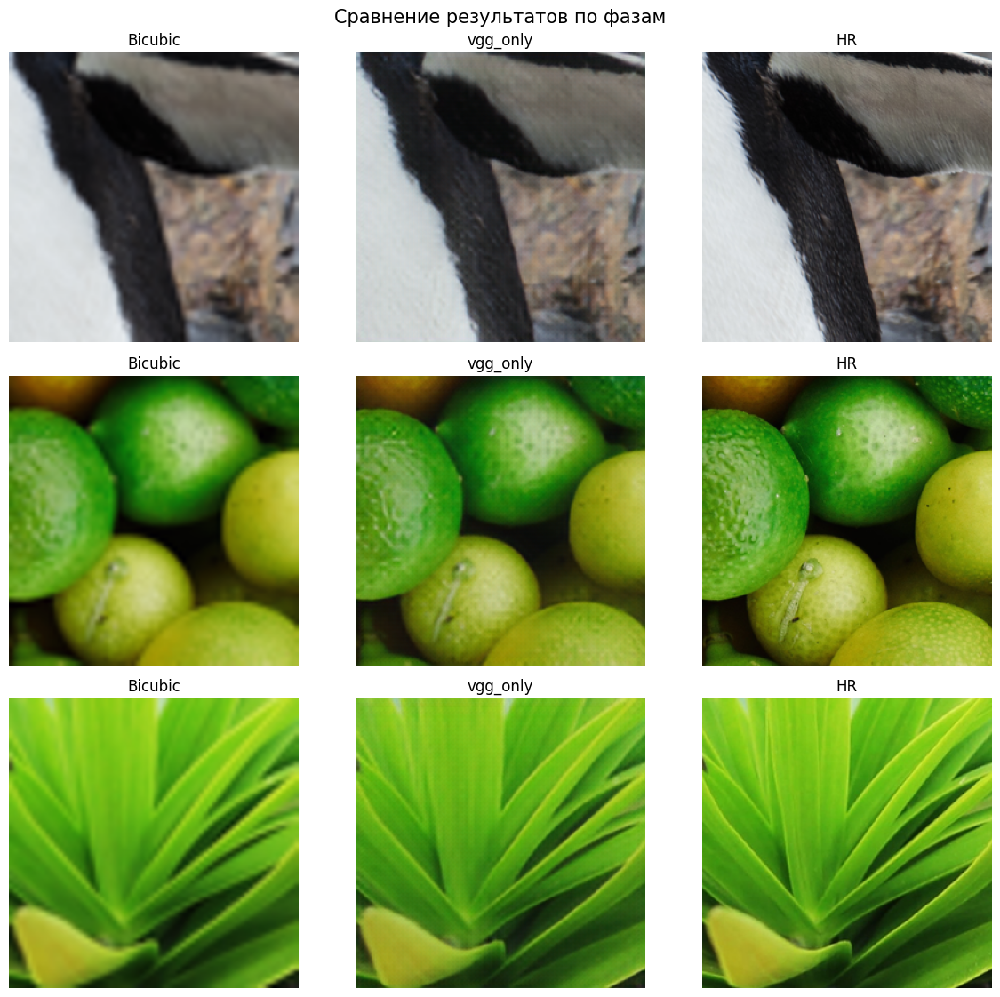

Лучший pretrain generator: checkpoints\best_pretrain_generator.pt


In [ ]:
train_phase(
    phase="pretrain",
    target_epochs=PRETRAIN_EPOCHS,
    g_lr=PRETRAIN_LR,
)

show_phase_comparison()

print("Лучший pretrain generator:", PRETRAIN_GENERATOR_PATH)

## 9. Запуск adversarial обучения

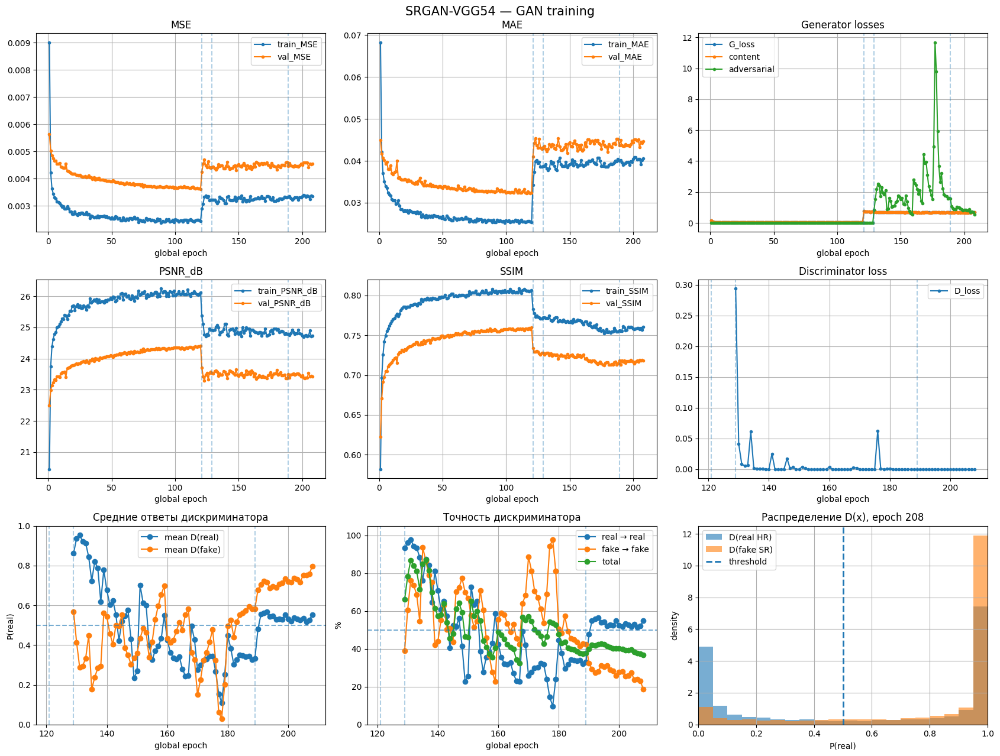

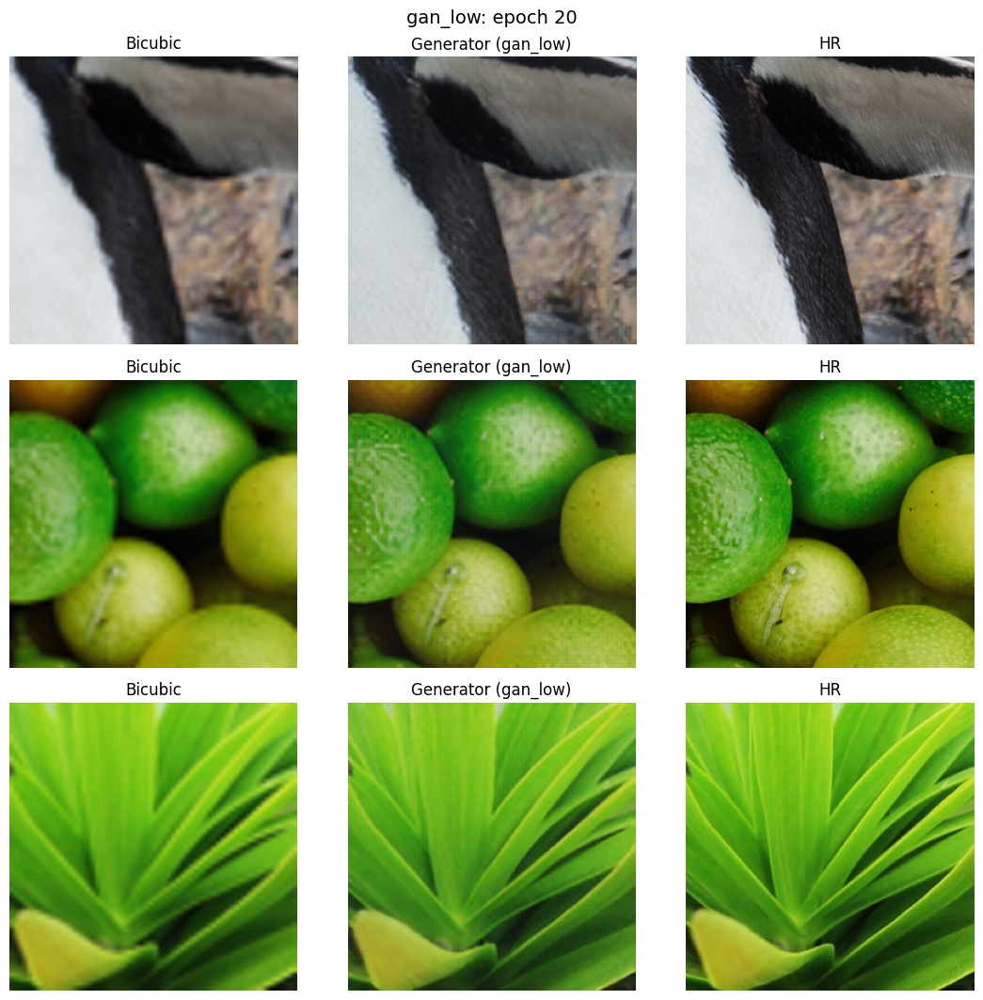

gan_low 20/20 | val PSNR=23.416 dB | val SSIM=0.7186 | D(real)=0.554 | D(fake)=0.798 | D acc=36.8%


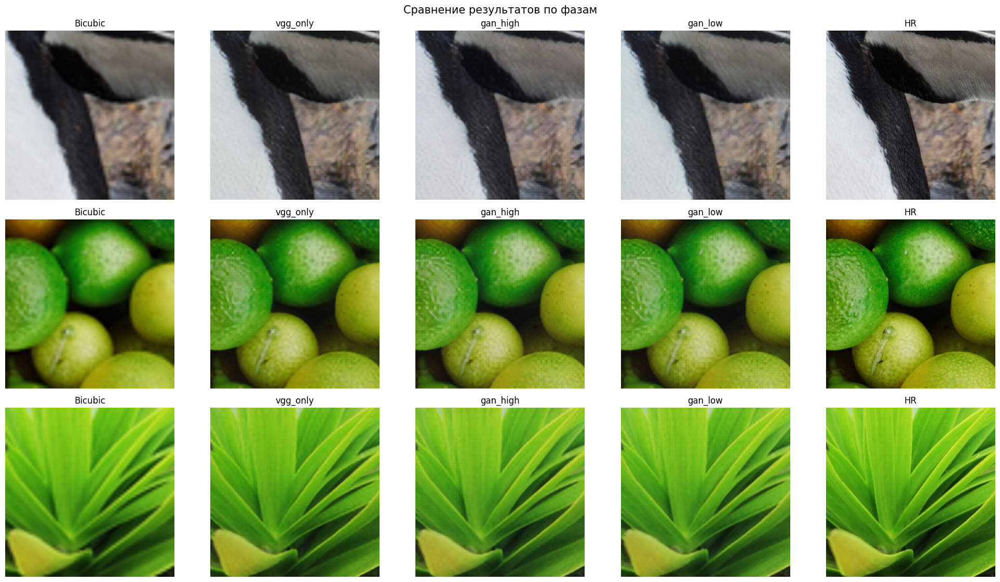

In [ ]:
# True:
#   - загрузить ТОЛЬКО лучший pretrain generator;
#   - полностью сбросить discriminator;
#   - сбросить optimizer/scaler;
#   - удалить старую VGG/GAN history.
#
# False:
#   - продолжать текущее состояние из latest checkpoint.
START_NEW_GAN_ATTEMPT_FROM_PRETRAIN = True

if START_NEW_GAN_ATTEMPT_FROM_PRETRAIN:
    prepare_new_gan_attempt_from_pretrain()


# 1. Мягкая адаптация генератора к VGG54 loss без discriminator.
# пришлось поддать несколько эпох на VGG54 loss, чтобы GAN не разваливался
train_phase(
    phase="vgg_only",
    target_epochs=VGG_ONLY_EPOCHS,
    g_lr=VGG_ONLY_LR,
)

show_phase_comparison()


# 2. GAN high phase.
train_phase(
    phase="gan_high",
    target_epochs=GAN_HIGH_EPOCHS,
    g_lr=GAN_G_LR_HIGH,
    d_lr=GAN_D_LR_HIGH,
)

show_phase_comparison()


# 3. GAN low phase.
train_phase(
    phase="gan_low",
    target_epochs=GAN_LOW_EPOCHS,
    g_lr=GAN_G_LR_LOW,
    d_lr=GAN_D_LR_LOW,
)

show_phase_comparison()


MSE - средняя квадратичная ошибка между восстановленным и исходным изображением. Чем меньше, тем ближе изображения по значениям пикселей.

MAE - средняя абсолютная ошибка пикселей. Чем меньше, тем лучше.

PSNR - показывает качество восстановления относительно пиксельной ошибки. Чем выше, тем лучше соответствие HR.

SSIM - оценивает сходство структуры, контраста и яркости изображений. Значение ближе к 1 означает большее структурное сходство.

Распределение D(x) - показывает распределение предсказанных вероятностей для настоящих и сгенерированных изображений. Чем сильнее распределения перекрываются, тем труднее дискриминатору их различать.

*Выводы по графикам*

До начала GAN-фазы обучение идет очень ровно: 
- validation MSE падает примерно до 0.0036–0.0037, 
- PSNR поднимается приблизительно до 24.4 dB, 
- SSIM примерно до 0.76. 

Разрыв между train и validation есть, но он выглядит естественным: train считается на случайных патчах, а validation - на другом фиксированном наборе.

После переключения на VGG/perceptual loss примерно на 120-й эпохе происходит заметный скачок:
- validation MSE растёт примерно с 0.0037 до 0.0044–0.0046;
- PSNR падает примерно с 24.4 до 23.4–23.6 dB;
- SSIM падает примерно с 0.76 до 0.72–0.73.

Появляется классический perception–distortion trade-off: визуально изображение может стать резче, хотя PSNR/SSIM ухудшаются.

На визуальных примерах это заметно: SR-изображения выглядят несколько более детализированными и контрастными, чем Bicubic, особенно на текстурах фруктов и листьев, хотя полностью HR-структуру модель не восстанавливает.

В общем можно сказать, что модель успешно обучилась выполнять super-resolution ×4. После перехода к perceptual и adversarial loss метрики снизились, однако изображения стали визуально более текстурированными и резкими. 

Таким образом, эксперимент показывает характерный для SRGAN компромисс между пиксельной точностью и perceptual quality. При этом финальная GAN-фаза оказалась не полностью стабильной, что видно по поведению дискриминатора.

## 10. Финальная оценка и визуальное сравнение

Final validation metrics: {'MSE': 0.004553567972441245, 'MAE': 0.04465170477232998, 'PSNR_dB': 23.4164817619897, 'SSIM': 0.7185697555541992}


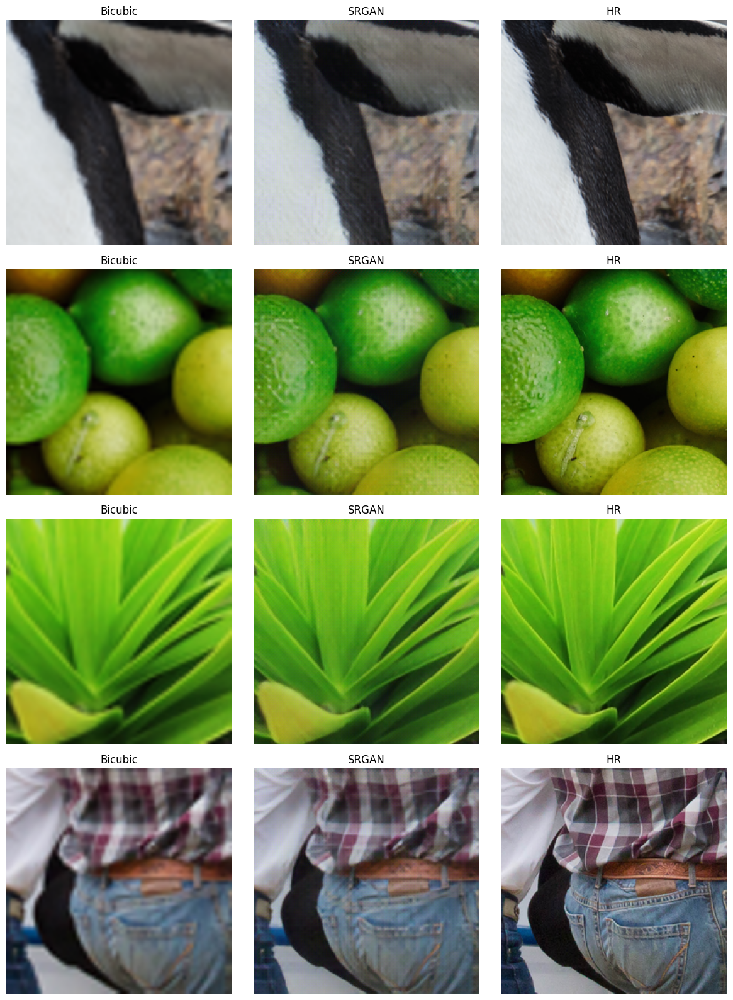

In [11]:
@torch.no_grad()
def show_validation_examples(n=4):
    G.eval()

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = axes[None, :]

    for i, (lr, hr) in enumerate(val_loader):
        if i >= n:
            break

        lr_d = lr.to(device, non_blocking=True)

        with torch.autocast(
            device_type=device.type,
            dtype=AMP_DTYPE,
            enabled=AMP_ENABLED,
        ):
            sr = G(lr_d).float().cpu()

        bicubic = TF.resize(
            lr[0],
            list(hr.shape[-2:]),
            interpolation=InterpolationMode.BICUBIC,
            antialias=True,
        )

        images = [bicubic.clamp(0,1), sr[0].clamp(0,1), hr[0].clamp(0,1)]
        titles = ["Bicubic", "SRGAN", "HR"]

        for j, (img, title) in enumerate(zip(images, titles)):
            axes[i, j].imshow(TF.to_pil_image(img))
            axes[i, j].set_title(title)
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()


metrics = evaluate_generator()
print("Final validation metrics:", metrics)
show_validation_examples(4)

In [17]:
@torch.no_grad()
def show_validation_sr(index=0):
    G.eval()

    current = 0
    lr = None
    hr = None

    for lr_batch, hr_batch in val_loader:
        bs = lr_batch.shape[0]

        if current + bs > index:
            local_idx = index - current
            lr = lr_batch[local_idx].cpu()
            hr = hr_batch[local_idx].cpu()
            break

        current += bs

    if lr is None:
        raise IndexError(
            f"Validation index {index} is out of range. "
            f"Dataset contains only {current} samples."
        )

    with torch.autocast(
        device_type=device.type,
        dtype=AMP_DTYPE,
        enabled=AMP_ENABLED,
    ):
        sr = G(lr.unsqueeze(0).to(device))[0]
        sr = sr.float().cpu().clamp(0, 1)

    bicubic = TF.resize(
        lr,
        size=list(hr.shape[-2:]),
        interpolation=TF.InterpolationMode.BICUBIC,
        antialias=True,
    ).clamp(0, 1)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    axes[0].imshow(TF.to_pil_image(lr))
    axes[0].set_title(f"LR, val #{index}")

    axes[1].imshow(TF.to_pil_image(bicubic))
    axes[1].set_title("Bicubic")

    axes[2].imshow(TF.to_pil_image(sr))
    axes[2].set_title("SRGAN")

    axes[3].imshow(TF.to_pil_image(hr))
    axes[3].set_title("HR")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return lr, bicubic, sr, hr

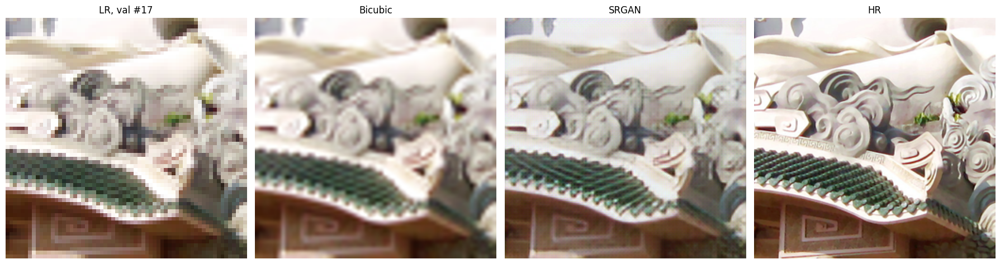

In [44]:
eboba = show_validation_sr(17)